<a href="https://colab.research.google.com/github/kat-miao/CUNY-Data-Analytics/blob/main/Project_3_Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
%matplotlib inline

Data source: https://data.cityofnewyork.us/Public-Safety/NYPD-Arrest-Data-Year-to-Date-/uip8-fykc/about_data

In [ ]:
# a method to upload data from desktop that I won't be using but would like to save in case I want to reference it in the future
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

Saving NYPD_Arrest_Data_(Year_to_Date)_20260416.csv to NYPD_Arrest_Data_(Year_to_Date)_20260416.csv


In [4]:
# data in Google Drive - "anyone with a link" <https://docs.google.com/spreadsheets/d/1MFqNpa2KCrXKPNE9on-bFLwp-xqgeYF1qRzHwolg1cU/edit?usp=sharing>
# For converting Google Sheets to .csv: replace "/edit?usp=sharing" with "/gviz/tq?tqx=out:csv" after unique URL
# load in data
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1MFqNpa2KCrXKPNE9on-bFLwp-xqgeYF1qRzHwolg1cU/gviz/tq?tqx=out:csv')

In [23]:
df.head(20)

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),NaN,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
5,301989860,03/03/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,43,0,45-64,M,BLACK,1020219,239110,40.822912,-73.870041,POINT (-73.8700413043181 40.8229123084767)
6,302130401,03/05/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,43,0,25-44,M,BLACK,1020183,239282,40.823387,-73.870170,POINT (-73.87017 40.823387)
7,302254604,03/08/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,40,0,25-44,M,BLACK,1005990,233847,40.808515,-73.921467,POINT (-73.921467 40.808515)
8,302692601,03/12/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,40,0,25-44,M,BLACK,1008067,236070,40.814611,-73.913956,POINT (-73.913956 40.814611)
9,303343948,03/21/2025,153,RAPE 3,104.0,RAPE,PL 1302507,F,K,78,0,25-44,M,WHITE HISPANIC,991330,187303,40.680786,-73.974475,POINT (-73.9744751162161 40.6807856126343)


In [24]:
#seeing structure of the data and column names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           131716 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [70]:
#seeing oldest and most recent date in database - only showing 2025 data

old_date = df['ARREST_DATE'].min()
recent_date = df['ARREST_DATE'].max()
print(old_date)
print(recent_date)

01/01/2025
12/31/2025


In [25]:
# seeing some of the stats
df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.789530e+05,278953.000000,278930.000000,278953.000000,278953.000000,2.789530e+05,278953.000000,278953.000000,278953.000000
mean,3.085697e+08,443.764512,258.919467,63.047255,0.932132,1.005315e+06,207515.629314,40.736243,-73.923782
std,5.664370e+06,274.632619,148.433045,34.798913,6.820188,2.235094e+04,29840.507845,0.081812,0.076414
min,2.987043e+08,12.000000,101.000000,1.000000,0.000000,-7.400000e+01,40.000000,40.500390,-74.252488
25%,3.038432e+08,157.000000,117.000000,40.000000,0.000000,9.906010e+05,184932.000000,40.674210,-73.977117
50%,3.086091e+08,439.000000,341.000000,62.000000,0.000000,1.005028e+06,206168.000000,40.732551,-73.924942
75%,3.135027e+08,724.000000,344.000000,100.000000,0.000000,1.017273e+06,235780.000000,40.813808,-73.880601
max,3.182749e+08,997.000000,995.000000,123.000000,97.000000,1.067185e+06,271597.000000,40.912111,-73.700719


Filtering data with some analysis

In [32]:
#cleaning values by removing (null)
df["PERP_SEX"] = df["PERP_SEX"].replace("(null)", np.nan)

In [36]:
#creating subset of columns to narrow down what I would like to analyze
c_subset = df[["OFNS_DESC", "PERP_SEX", "PERP_RACE"]]
c_subset.head(20)

,OFNS_DESC,PERP_SEX,PERP_RACE
0,FELONY ASSAULT,F,WHITE
1,FELONY ASSAULT,M,BLACK
2,RAPE,M,BLACK HISPANIC
3,RAPE,NaN,BLACK
4,RAPE,M,BLACK
5,RAPE,M,BLACK
6,FELONY ASSAULT,M,BLACK
7,FELONY ASSAULT,M,BLACK
8,FELONY ASSAULT,M,BLACK
9,RAPE,M,WHITE HISPANIC


In [42]:
#seeing the different crimes committed
c_subset["OFNS_DESC"].unique()

array(['FELONY ASSAULT', 'RAPE', 'ARSON', 'OTHER STATE LAWS',
       'SEX CRIMES', 'JOSTLING', 'DANGEROUS WEAPONS',
       'ASSAULT 3 & RELATED OFFENSES', 'POSSESSION OF STOLEN PROPERTY',
       'OFFENSES AGAINST PUBLIC ADMINI', 'OTHER TRAFFIC INFRACTION',
       'CRIMINAL TRESPASS', 'DANGEROUS DRUGS',
       'CRIMINAL MISCHIEF & RELATED OF',
       'OTHER OFFENSES RELATED TO THEFT', 'VEHICLE AND TRAFFIC LAWS',
       'GRAND LARCENY', 'MISCELLANEOUS PENAL LAW', 'PETIT LARCENY',
       'BURGLARY', 'OFF. AGNST PUB ORD SENSBLTY &',
       'GRAND LARCENY OF MOTOR VEHICLE', 'FORGERY', 'ROBBERY', 'FRAUDS',
       'UNAUTHORIZED USE OF A VEHICLE', 'OFFENSES INVOLVING FRAUD',
       'FOR OTHER AUTHORITIES', 'INTOXICATED & IMPAIRED DRIVING',
       'OFFENSES AGAINST THE PERSON', 'MURDER & NON-NEGL. MANSLAUGHTE',
       'ADMINISTRATIVE CODE', "BURGLAR'S TOOLS",
       'ALCOHOLIC BEVERAGE CONTROL LAW', 'OFFENSES RELATED TO CHILDREN',
       'PROSTITUTION & RELATED OFFENSES', 'ANTICIPATORY OFFENSES

In [64]:
#using .size() to see how many counts of the crime there are to use for selection
c_subset.groupby(["OFNS_DESC"]).size()

,0
OFNS_DESC,
(null),23
ADMINISTRATIVE CODE,163
ADMINISTRATIVE CODES,4
ALCOHOLIC BEVERAGE CONTROL LAW,237
ANTICIPATORY OFFENSES,268
...,...
THEFT-FRAUD,313
UNAUTHORIZED USE OF A VEHICLE,526
UNDER THE INFLUENCE OF DRUGS,2


Question: Which race and sex are typically harrassing people?

In [65]:
#choosing one crime to analyze. Selection is case-senstive.
theft_fraud = c_subset[(c_subset['OFNS_DESC'] == "THEFT-FRAUD")]
theft_fraud.head(20)

,OFNS_DESC,PERP_SEX,PERP_RACE
702,THEFT-FRAUD,NaN,WHITE HISPANIC
2973,THEFT-FRAUD,NaN,WHITE HISPANIC
3489,THEFT-FRAUD,NaN,BLACK
5085,THEFT-FRAUD,NaN,BLACK
7087,THEFT-FRAUD,NaN,WHITE
9013,THEFT-FRAUD,NaN,WHITE HISPANIC
9688,THEFT-FRAUD,NaN,WHITE
10834,THEFT-FRAUD,F,ASIAN / PACIFIC ISLANDER
12602,THEFT-FRAUD,NaN,WHITE
13286,THEFT-FRAUD,NaN,BLACK HISPANIC


Analyzing Data

In [66]:
#using groupby to see the count of the perpetrator's race and sex. .size() is used to count PERP_RACE and PERP_SEX
theft_fraud.groupby(["PERP_RACE", "PERP_SEX", "OFNS_DESC"]).size()

PERP_RACE                       PERP_SEX  OFNS_DESC  
AMERICAN INDIAN/ALASKAN NATIVE  F         THEFT-FRAUD     1
ASIAN / PACIFIC ISLANDER        F         THEFT-FRAUD     5
                                M         THEFT-FRAUD    17
BLACK                           F         THEFT-FRAUD     6
                                M         THEFT-FRAUD    35
BLACK HISPANIC                  F         THEFT-FRAUD     3
                                M         THEFT-FRAUD    17
UNKNOWN                         M         THEFT-FRAUD     1
WHITE                           F         THEFT-FRAUD     3
                                M         THEFT-FRAUD    15
WHITE HISPANIC                  F         THEFT-FRAUD     5
                                M         THEFT-FRAUD    23
dtype: int64

<Axes: title={'center': 'Theft/Fraud Perpetrators in CY2025'}, xlabel='race, sex', ylabel='Count of person'>

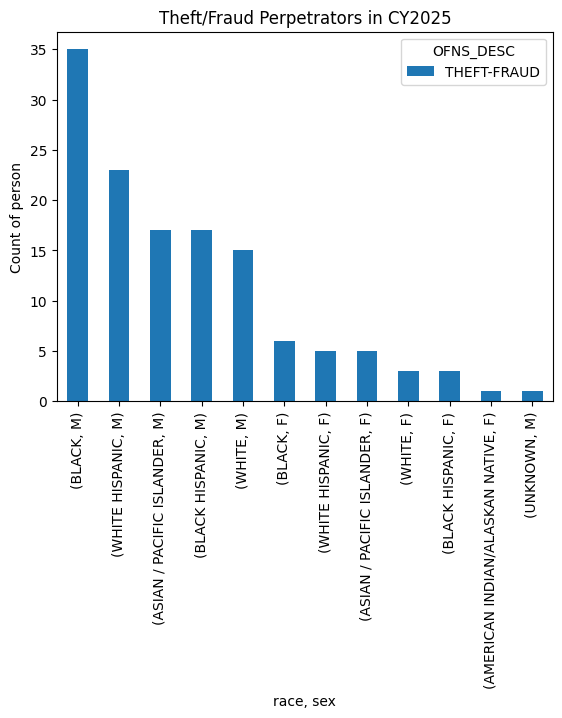

In [78]:
# plot data by using .unstack() data to prepare for visualization and rename function
plot_data = theft_fraud.groupby(["PERP_RACE", "PERP_SEX", "OFNS_DESC"]).size().unstack()

#sort values from largest to smallest
plot_data = plot_data.sort_values(by="THEFT-FRAUD", ascending=False)

#plot bar graph
plot_data.plot(
    kind = "bar",
    xlabel = "race, sex",
    ylabel = "Count of person",
    title = "Theft/Fraud Perpetrators in CY2025"
)

Conclusion: This dataset is only looking at crime perpetrators committed in calendar year 2025. There isn't any data about the victims in this dataset. I focused on theft/fraud because it had a high count based on data I could see.

Based on my findings, perpetrators tend to be male in sex and black in race. The NYPD may have a high bias for targetting black males as well.